Loading student_performance.csv...
✓ Loaded 120 student records
✓ Variables: Study_Hours, Sleep_Hours, Screen_Time, Attendance_Percent, Exam_Score

CORRELATION MATRIX (Pearson Correlation Coefficient)
                    Study_Hours  Sleep_Hours  Screen_Time  Attendance_Percent  \
Study_Hours              1.0000      -0.0509      -0.0055              0.3561   
Sleep_Hours             -0.0509       1.0000      -0.2991             -0.1250   
Screen_Time             -0.0055      -0.2991       1.0000              0.1301   
Attendance_Percent       0.3561      -0.1250       0.1301              1.0000   
Exam_Score               0.8161      -0.0201       0.0491              0.4018   

                    Exam_Score  
Study_Hours             0.8161  
Sleep_Hours            -0.0201  
Screen_Time             0.0491  
Attendance_Percent      0.4018  
Exam_Score              1.0000  

STRONGEST POSITIVE CORRELATION
Variable 1: Study_Hours
Variable 2: Exam_Score
Correlation: r = 0.8161
R-squared: 

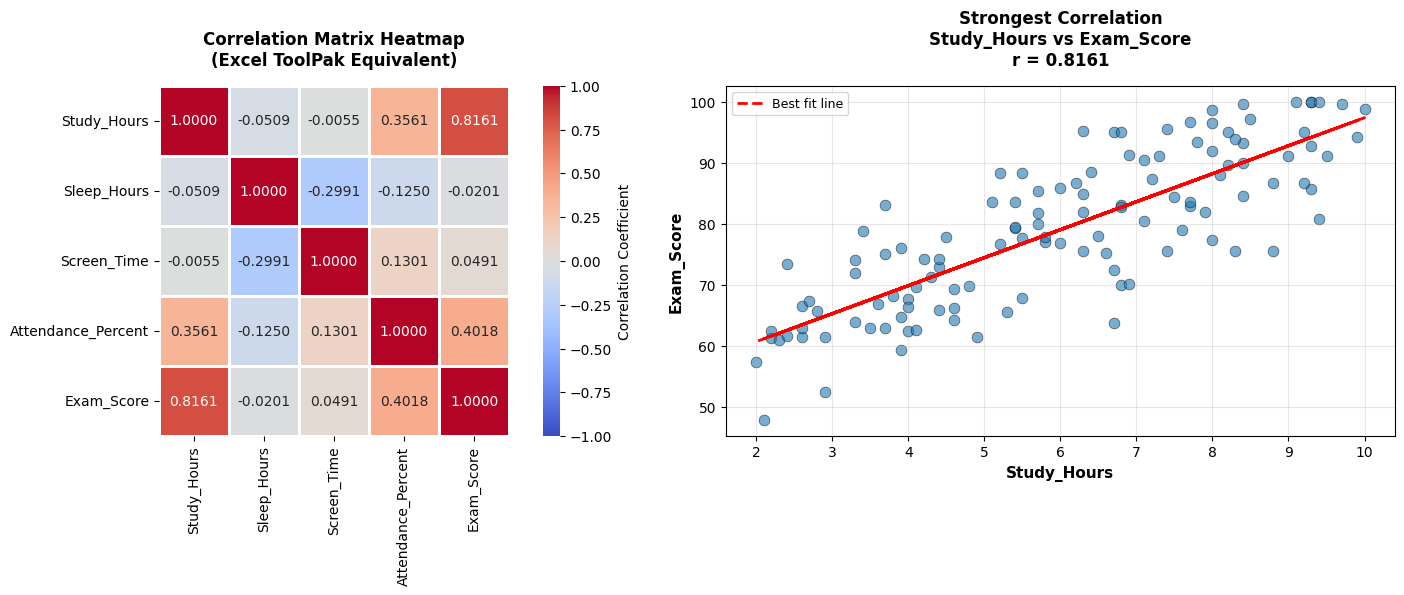

In [ ]:
"""
Student Performance Correlation Analysis
Replicates Excel Data Analysis ToolPak functionality
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    # Load data
    print("Loading student_performance.csv...")
    df = pd.read_csv('student_performance.csv')

    print(f"✓ Loaded {len(df)} student records")
    print(f"✓ Variables: {', '.join(df.columns.tolist())}\n")

    # Calculate Pearson correlation matrix
    print("="*70)
    print("CORRELATION MATRIX (Pearson Correlation Coefficient)")
    print("="*70)
    correlation_matrix = df.corr(method='pearson')
    print(correlation_matrix.round(4))

    # Find strongest positive correlation (excluding diagonal)
    corr_array = correlation_matrix.values.copy()
    corr_names = correlation_matrix.columns.tolist()

    # Set diagonal to NaN (exclude self-correlations)
    np.fill_diagonal(corr_array, np.nan)

    # Find maximum correlation
    max_corr = np.nanmax(corr_array)
    max_location = np.where(corr_array == max_corr)

    var1 = corr_names[max_location[0][0]]
    var2 = corr_names[max_location[1][0]]

    # Display results
    print("\n" + "="*70)
    print("STRONGEST POSITIVE CORRELATION")
    print("="*70)
    print(f"Variable 1: {var1}")
    print(f"Variable 2: {var2}")
    print(f"Correlation: r = {max_corr:.4f}")
    print(f"R-squared: R² = {max_corr**2:.4f}")
    print(f"Variance Explained: {max_corr**2*100:.2f}%")

    # Interpretation
    if max_corr >= 0.80:
        strength = "Very strong"
    elif max_corr >= 0.60:
        strength = "Strong"
    elif max_corr >= 0.40:
        strength = "Moderate"
    elif max_corr >= 0.20:
        strength = "Weak"
    else:
        strength = "Very weak"

    print(f"\nInterpretation: {strength} positive correlation")
    print("This means as one variable increases, the other tends to increase.")
    print("⚠️  Remember: Correlation does NOT imply causation!")

    # All correlations sorted
    print("\n" + "="*70)
    print("ALL VARIABLE PAIRS (Sorted by Correlation)")
    print("="*70)

    # Extract upper triangle to avoid duplicates
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    all_corr = upper_triangle.stack().sort_values(ascending=False)

    for (v1, v2), corr in all_corr.items():
        print(f"{v1:20s} ↔ {v2:20s} | r = {corr:7.4f}")

    # Final answer
    print("\n" + "#"*70)
    print("#" + " "*68 + "#")
    print("#" + " "*20 + "SUBMISSION ANSWER" + " "*31 + "#")
    print("#" + " "*68 + "#")
    print("#"*70)
    print(f"\n  {var1}, {var2}, {max_corr:.4f}\n")
    print("#"*70)

    # Create visualization
    create_visualization(df, correlation_matrix, var1, var2, max_corr)

def create_visualization(df, correlation_matrix, var1, var2, max_corr):
    """Create correlation heatmap and scatter plot"""

    # Create figure with subplots
    fig = plt.figure(figsize=(16, 6))

    # Subplot 1: Correlation Heatmap
    ax1 = plt.subplot(1, 2, 1)
    sns.heatmap(correlation_matrix,
                annot=True,
                fmt='.4f',
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=1,
                cbar_kws={'label': 'Correlation Coefficient'},
                vmin=-1, vmax=1,
                ax=ax1)
    ax1.set_title('Correlation Matrix Heatmap\n(Excel ToolPak Equivalent)',
                  fontsize=12, fontweight='bold', pad=15)

    # Subplot 2: Scatter plot of strongest correlation
    ax2 = plt.subplot(1, 2, 2)
    ax2.scatter(df[var1], df[var2], alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

    # Add regression line
    z = np.polyfit(df[var1], df[var2], 1)
    p = np.poly1d(z)
    ax2.plot(df[var1], p(df[var1]), "r--", linewidth=2, label='Best fit line')

    ax2.set_xlabel(var1, fontsize=11, fontweight='bold')
    ax2.set_ylabel(var2, fontsize=11, fontweight='bold')
    ax2.set_title(f'Strongest Correlation\n{var1} vs {var2}\nr = {max_corr:.4f}',
                  fontsize=12, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Visualization saved as 'correlation_analysis.png'")
    plt.show()

if __name__ == "__main__":
    main()